# Movement Data Discovery
## Phase 1: Career Pathway Enhancement with Historical Movement Data

**Objective**: Initial exploration of movement patterns and data quality from synthetic but realistic workforce movement data.

**Data Sources**:
- `realistic_movement_fact_table.csv` - 5,543 movement records (2022-2024)
- SQLite database - Job architecture and skills context

**Key Questions**:
1. What are the volume patterns of movements over time?
2. Which job functions see the most mobility (in/out flows)?
3. How do cross-function vs same-function moves compare?
4. What's the distribution of tenure before movement?


In [1]:
# Data loading and setup
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("📊 Movement Data Discovery - Phase 1")
print("=" * 50)

📊 Movement Data Discovery - Phase 1


In [2]:
# Load movement data
movement_file = "../data/synthetic_test/movement_analysis/realistic_movement_fact_table.csv"
movement_df = pd.read_csv(movement_file)

print(f"📁 Loaded movement data: {len(movement_df):,} records")
print(f"📅 Date range: {movement_df['movement_year'].min()} - {movement_df['movement_year'].max()}")
print(f"🔄 Movement types: {movement_df['predominant_movement_type'].value_counts().to_dict()}")

# Basic info
print("\n📋 Dataset Overview:")
print(movement_df.info())

print("\n📊 First 5 records:")
movement_df.head()

📁 Loaded movement data: 8,422 records
📅 Date range: 2020 - 2025
🔄 Movement types: {'lateral': 8422}

📋 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8422 entries, 0 to 8421
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   fact_id                    8422 non-null   int64  
 1   movement_month             8422 non-null   object 
 2   movement_year              8422 non-null   int64  
 3   from_position              8422 non-null   int64  
 4   to_position                8422 non-null   int64  
 5   movement_pattern           8422 non-null   object 
 6   movement_count             8422 non-null   int64  
 7   pct_total_movements        8422 non-null   float64
 8   unique_employees           8422 non-null   int64  
 9   avg_days_between           8422 non-null   float64
 10  monthly_total_movements    8422 non-null   int64  
 11  predominant_movement_type  8422 non-nul

,fact_id,movement_month,movement_year,from_position,to_position,movement_pattern,movement_count,pct_total_movements,unique_employees,avg_days_between,monthly_total_movements,predominant_movement_type
0,1,2020-07,2020,50002938,50003928,50002938 → 50003928,5,1.99,5,797.9,162,lateral
1,2,2020-07,2020,50003376,50003486,50003376 → 50003486,2,0.80,2,634.1,162,lateral
2,3,2020-07,2020,50003083,50004752,50003083 → 50004752,1,0.40,1,975.7,162,lateral
3,4,2020-07,2020,50000987,50001218,50000987 → 50001218,2,0.80,2,567.8,162,lateral
4,5,2020-07,2020,50002444,50004107,50002444 → 50004107,3,1.20,3,845.7,162,lateral


In [3]:
# Connect to SQLite database for job context
db_path = "../models/2025-Q3/workforce_intelligence.sqlite"
conn = sqlite3.connect(db_path)

# Load job architecture data
jobs_df = pd.read_sql_query("SELECT * FROM jobs", conn)
print(f"🏢 Loaded jobs data: {len(jobs_df):,} job profiles")

# Check job hierarchy structure
print("\n🏗️ Job Architecture Hierarchy:")
print(f"Job Functions: {jobs_df['JobFunction'].nunique()}")
print(f"Job Sub-Functions: {jobs_df['JobSubFunction'].nunique()}")
print(f"Management Levels: {jobs_df['ManagementLevel'].nunique()}")
print(f"Job Categories: {jobs_df['JobCategory'].nunique()}")

print("\n📋 Job Functions:")
print(jobs_df['JobFunction'].value_counts().head(10))

🏢 Loaded jobs data: 715 job profiles

🏗️ Job Architecture Hierarchy:
Job Functions: 22
Job Sub-Functions: 110
Management Levels: 8
Job Categories: 4

📋 Job Functions:
JobFunction
Operations & Processing        78
Risk Management                55
Finance & Treasury             54
Facilities & Administration    51
Banking Services               45
Investment Management          44
Data & Analytics               41
Technology & Engineering       36
Marketing & Communications     35
Research & Analysis            33
Name: count, dtype: int64


In [5]:
# Load positions data to bridge movement positions to job profiles
positions_df = pd.read_sql_query("SELECT * FROM positions", conn)
print(f"🏢 Loaded positions data: {len(positions_df):,} position records")

# Debug data types and sample values
print(f"\n🔍 Data Type Analysis:")
print(f"Movement 'from_position' type: {movement_df['from_position'].dtype}")
print(f"Movement 'from_position' sample: {movement_df['from_position'].head().tolist()}")
print(f"Positions 'Position Number' type: {positions_df['Position Number'].dtype}")
print(f"Positions 'Position Number' sample: {positions_df['Position Number'].head().tolist()}")

# Convert Position Number to string to match movement data format
positions_df['Position Number'] = positions_df['Position Number'].astype(str)
movement_df['from_position'] = movement_df['from_position'].astype(str)
movement_df['to_position'] = movement_df['to_position'].astype(str)

print(f"\n🔄 After conversion:")
print(f"Movement 'from_position' type: {movement_df['from_position'].dtype}")
print(f"Positions 'Position Number' type: {positions_df['Position Number'].dtype}")

# Step 1: Merge movement data with positions for 'from' positions
movement_with_context = movement_df.merge(
    positions_df[['Position Number', 'JobProfileID']],
    left_on='from_position',
    right_on='Position Number',
    how='left',
    suffixes=('', '_pos_from')
).drop('Position Number', axis=1)

# Step 2: Merge with positions for 'to' positions
movement_with_context = movement_with_context.merge(
    positions_df[['Position Number', 'JobProfileID']],
    left_on='to_position',
    right_on='Position Number',
    how='left',
    suffixes=('_from', '_to')
).drop('Position Number', axis=1)

# Step 3: Add job architecture context for 'from' positions
movement_with_context = movement_with_context.merge(
    jobs_df[['JobProfileID', 'JobFunction', 'JobSubFunction', 'ManagementLevel', 'JobCategory']],
    left_on='JobProfileID_from',
    right_on='JobProfileID',
    how='left',
    suffixes=('', '_from')
).drop('JobProfileID', axis=1)

# Step 4: Add job architecture context for 'to' positions
movement_with_context = movement_with_context.merge(
    jobs_df[['JobProfileID', 'JobFunction', 'JobSubFunction', 'ManagementLevel', 'JobCategory']],
    left_on='JobProfileID_to',
    right_on='JobProfileID',
    how='left',
    suffixes=('_from', '_to')
).drop('JobProfileID', axis=1)

print(f"🔗 Merged dataset: {len(movement_with_context):,} records")
print(f"📊 From positions with job context: {movement_with_context['JobFunction_from'].notna().sum():,}")
print(f"📊 To positions with job context: {movement_with_context['JobFunction_to'].notna().sum():,}")

# Check merge quality
successful_merges = (movement_with_context['JobFunction_from'].notna() & 
                    movement_with_context['JobFunction_to'].notna()).sum()
print(f"\n✅ Successful full merges: {successful_merges:,} / {len(movement_with_context):,} ({successful_merges/len(movement_with_context)*100:.1f}%)")

# Check position number coverage
from_pos_coverage = movement_with_context['JobProfileID_from'].notna().sum()
to_pos_coverage = movement_with_context['JobProfileID_to'].notna().sum()
print(f"📋 Position Number Coverage:")
print(f"  From positions: {from_pos_coverage:,} / {len(movement_with_context):,} ({from_pos_coverage/len(movement_with_context)*100:.1f}%)")
print(f"  To positions: {to_pos_coverage:,} / {len(movement_with_context):,} ({to_pos_coverage/len(movement_with_context)*100:.1f}%)")

🏢 Loaded positions data: 35,000 position records

🔍 Data Type Analysis:
Movement 'from_position' type: int64
Movement 'from_position' sample: [50002938, 50003376, 50003083, 50000987, 50002444]
Positions 'Position Number' type: object
Positions 'Position Number' sample: ['50003311', '50003667', '50000226', '50004844', '50003090']

🔄 After conversion:
Movement 'from_position' type: object
Positions 'Position Number' type: object
🔗 Merged dataset: 401,643 records
📊 From positions with job context: 401,625
📊 To positions with job context: 401,566

✅ Successful full merges: 401,548 / 401,643 (100.0%)
📋 Position Number Coverage:
  From positions: 401,625 / 401,643 (100.0%)
  To positions: 401,566 / 401,643 (100.0%)


## 1. Movement Volume Patterns

Let's explore the temporal patterns and volume of movements to understand baseline activity.


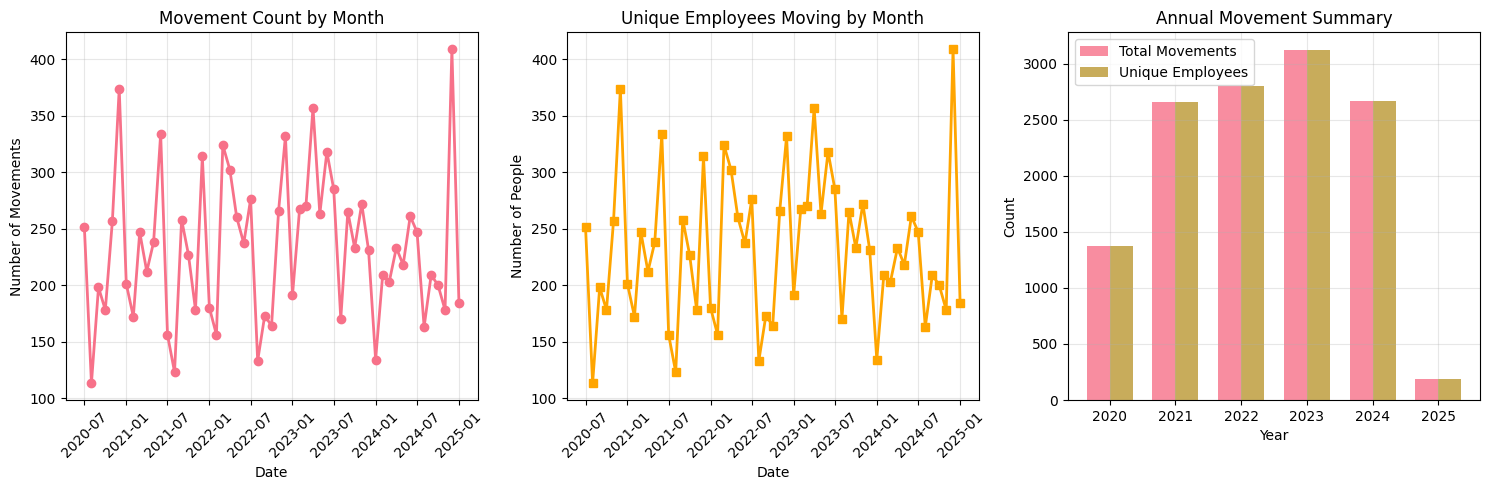

📊 Movement Volume Summary:
Total movements: 12,804
Unique employees: 12,804
Average movements per month: 232.8


In [7]:
# Movement volume over time
plt.figure(figsize=(15, 5))

# Create monthly time series
movement_df['date'] = pd.to_datetime(movement_df['movement_month'] + '-01')
monthly_volume = movement_df.groupby('date').agg({
    'movement_count': 'sum',
    'unique_employees': 'sum',
    'monthly_total_movements': 'first'
}).reset_index()

# Plot 1: Total movements per month
plt.subplot(1, 3, 1)
plt.plot(monthly_volume['date'], monthly_volume['movement_count'], marker='o', linewidth=2)
plt.title('Movement Count by Month')
plt.xlabel('Date')
plt.ylabel('Number of Movements')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Unique employees moving per month
plt.subplot(1, 3, 2)
plt.plot(monthly_volume['date'], monthly_volume['unique_employees'], marker='s', color='orange', linewidth=2)
plt.title('Unique Employees Moving by Month')
plt.xlabel('Date')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: Movement trends by year
plt.subplot(1, 3, 3)
yearly_stats = movement_df.groupby('movement_year').agg({
    'movement_count': 'sum',
    'unique_employees': 'sum'
}).reset_index()

x = np.arange(len(yearly_stats))
width = 0.35
plt.bar(x - width/2, yearly_stats['movement_count'], width, label='Total Movements', alpha=0.8)
plt.bar(x + width/2, yearly_stats['unique_employees'], width, label='Unique Employees', alpha=0.8)
plt.title('Annual Movement Summary')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(x, yearly_stats['movement_year'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Movement Volume Summary:")
print(f"Total movements: {movement_df['movement_count'].sum():,}")
print(f"Unique employees: {movement_df['unique_employees'].sum():,}")
print(f"Average movements per month: {monthly_volume['movement_count'].mean():.1f}")


## 2. Function-Level Mobility Analysis

Analysing which job functions are sources vs sinks for talent movement.


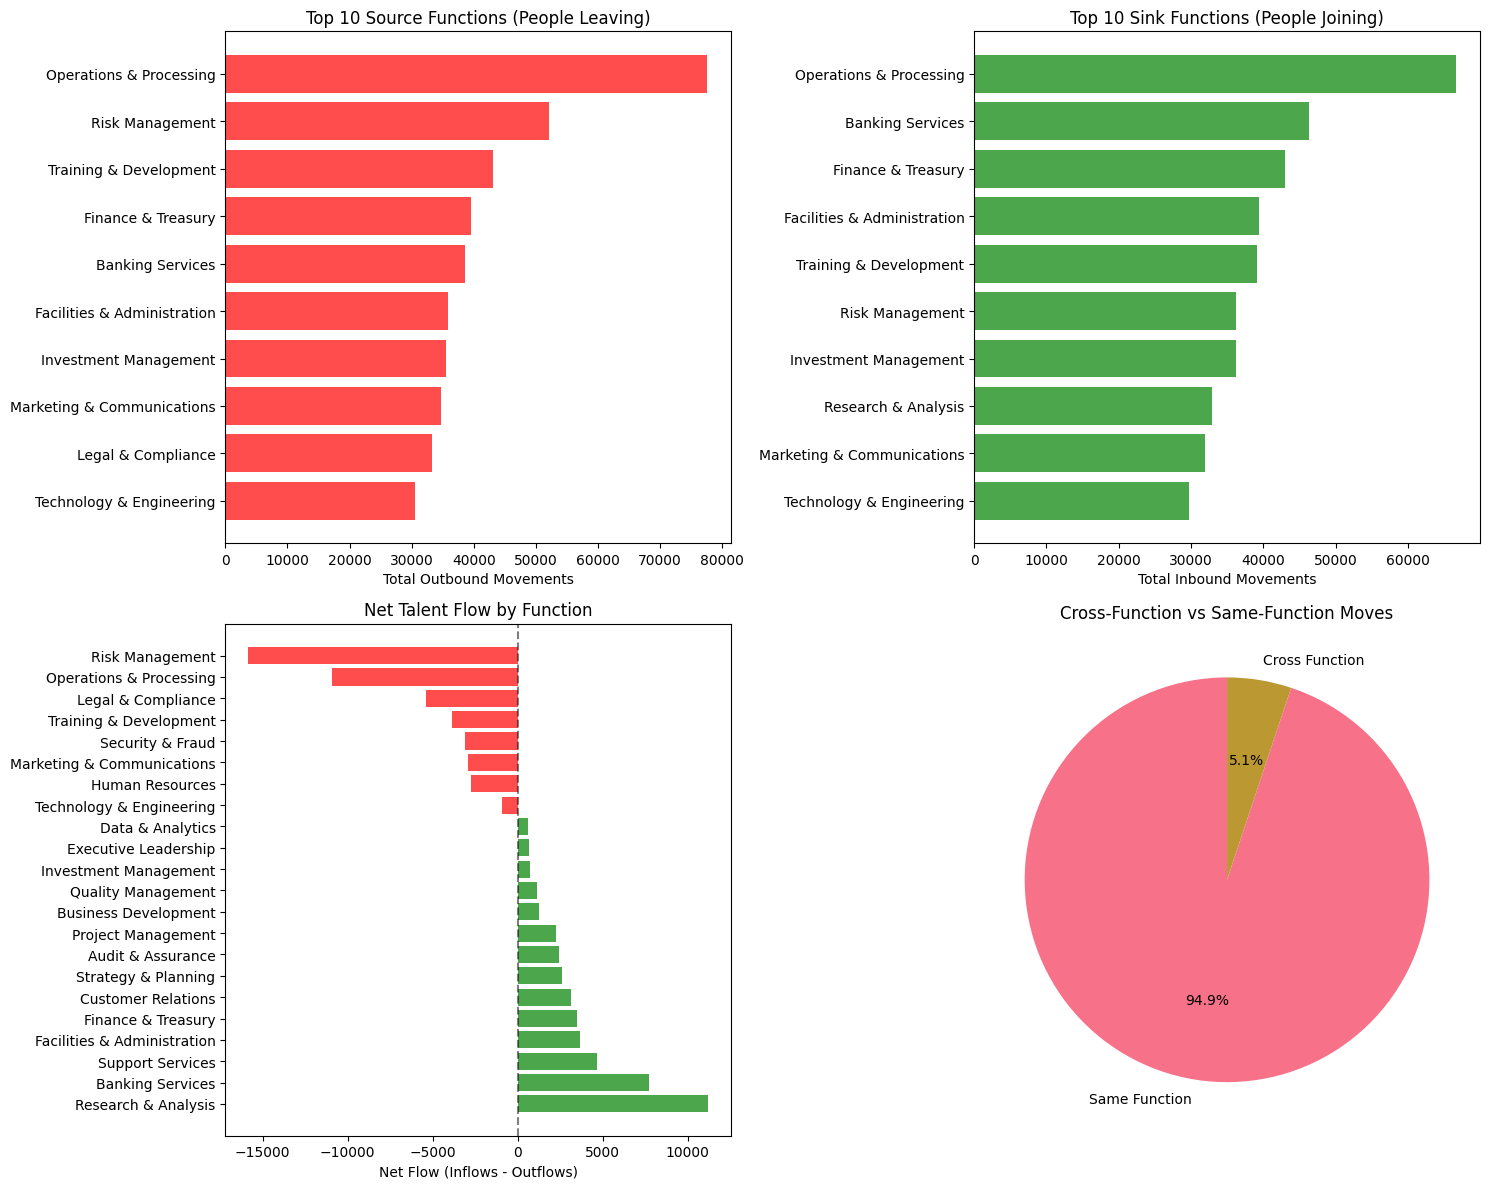

🔄 Function Mobility Summary:
Cross-function moves: 380,942 (94.9%)

Top 5 Source Functions (Outflows):
  Operations & Processing: 77575 movements
  Risk Management: 52084 movements
  Training & Development: 43051 movements
  Finance & Treasury: 39550 movements
  Banking Services: 38612 movements

Top 5 Sink Functions (Inflows):
  Operations & Processing: 66648 movements
  Banking Services: 46321 movements
  Finance & Treasury: 43056 movements
  Facilities & Administration: 39470 movements
  Training & Development: 39184 movements


In [9]:
# Function mobility patterns
valid_movements = movement_with_context.dropna(subset=['JobFunction_from', 'JobFunction_to'])

# Create cross-function move indicator
valid_movements['cross_function_move'] = (valid_movements['JobFunction_from'] != valid_movements['JobFunction_to'])

# Calculate outflows (people leaving each function)
outflows = valid_movements.groupby('JobFunction_from')['movement_count'].sum().sort_values(ascending=False)

# Calculate inflows (people joining each function)  
inflows = valid_movements.groupby('JobFunction_to')['movement_count'].sum().sort_values(ascending=False)

# Net flow (inflows - outflows)
all_functions = set(outflows.index) | set(inflows.index)
net_flow = pd.Series(index=list(all_functions))
for func in all_functions:
    in_val = inflows.get(func, 0)
    out_val = outflows.get(func, 0)
    net_flow[func] = in_val - out_val

# Create mobility analysis
plt.figure(figsize=(15, 12))

# Plot 1: Top sources (outflows)
plt.subplot(2, 2, 1)
top_sources = outflows.head(10)
plt.barh(range(len(top_sources)), top_sources.values, alpha=0.7, color='red')
plt.yticks(range(len(top_sources)), top_sources.index)
plt.xlabel('Total Outbound Movements')
plt.title('Top 10 Source Functions (People Leaving)')
plt.gca().invert_yaxis()

# Plot 2: Top sinks (inflows)
plt.subplot(2, 2, 2)
top_sinks = inflows.head(10)
plt.barh(range(len(top_sinks)), top_sinks.values, alpha=0.7, color='green')
plt.yticks(range(len(top_sinks)), top_sinks.index)
plt.xlabel('Total Inbound Movements')
plt.title('Top 10 Sink Functions (People Joining)')
plt.gca().invert_yaxis()

# Plot 3: Net flow analysis
plt.subplot(2, 2, 3)
net_flow_sorted = net_flow.sort_values()
colors = ['red' if x < 0 else 'green' for x in net_flow_sorted.values]
plt.barh(range(len(net_flow_sorted)), net_flow_sorted.values, alpha=0.7, color=colors)
plt.yticks(range(len(net_flow_sorted)), net_flow_sorted.index)
plt.xlabel('Net Flow (Inflows - Outflows)')
plt.title('Net Talent Flow by Function')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()

# Plot 4: Cross-function vs same-function moves
plt.subplot(2, 2, 4)
cross_function_stats = valid_movements['cross_function_move'].value_counts()
plt.pie(cross_function_stats.values, labels=['Same Function', 'Cross Function'], autopct='%1.1f%%', startangle=90)
plt.title('Cross-Function vs Same-Function Moves')

plt.tight_layout()
plt.show()

print("🔄 Function Mobility Summary:")
print(f"Cross-function moves: {valid_movements['cross_function_move'].sum():,} ({valid_movements['cross_function_move'].mean()*100:.1f}%)")
print(f"\nTop 5 Source Functions (Outflows):")
for func, count in outflows.head().items():
    print(f"  {func}: {count} movements")
    
print(f"\nTop 5 Sink Functions (Inflows):")
for func, count in inflows.head().items():
    print(f"  {func}: {count} movements")


## 3. Movement Corridors Analysis

Identifying the most common movement pathways between specific roles.


🚶 Top 20 Movement Corridors:
50004494 → 50002546
  Volume: 4032 moves, 4032 people
  Function: Training & Development → Legal & Compliance
  Avg Tenure: 24.0 months

50001408 → 50001708
  Volume: 2912 moves, 2912 people
  Function: Investment Management → Data & Analytics
  Avg Tenure: 25.0 months

50001177 → 50004760
  Volume: 2574 moves, 2574 people
  Function: Operations & Processing → Banking Services
  Avg Tenure: 25.5 months

50000160 → 50004493
  Volume: 2420 moves, 2420 people
  Function: Banking Services → Quality Management
  Avg Tenure: 21.3 months

50004057 → 50000784
  Volume: 2400 moves, 2400 people
  Function: Banking Services → Research & Analysis
  Avg Tenure: 23.5 months

50002279 → 50000788
  Volume: 2366 moves, 2366 people
  Function: Data & Analytics → Support Services
  Avg Tenure: 24.7 months

50003146 → 50000412
  Volume: 2340 moves, 2340 people
  Function: Risk Management → Banking Services
  Avg Tenure: 25.4 months

50001388 → 50001856
  Volume: 2268 moves, 22

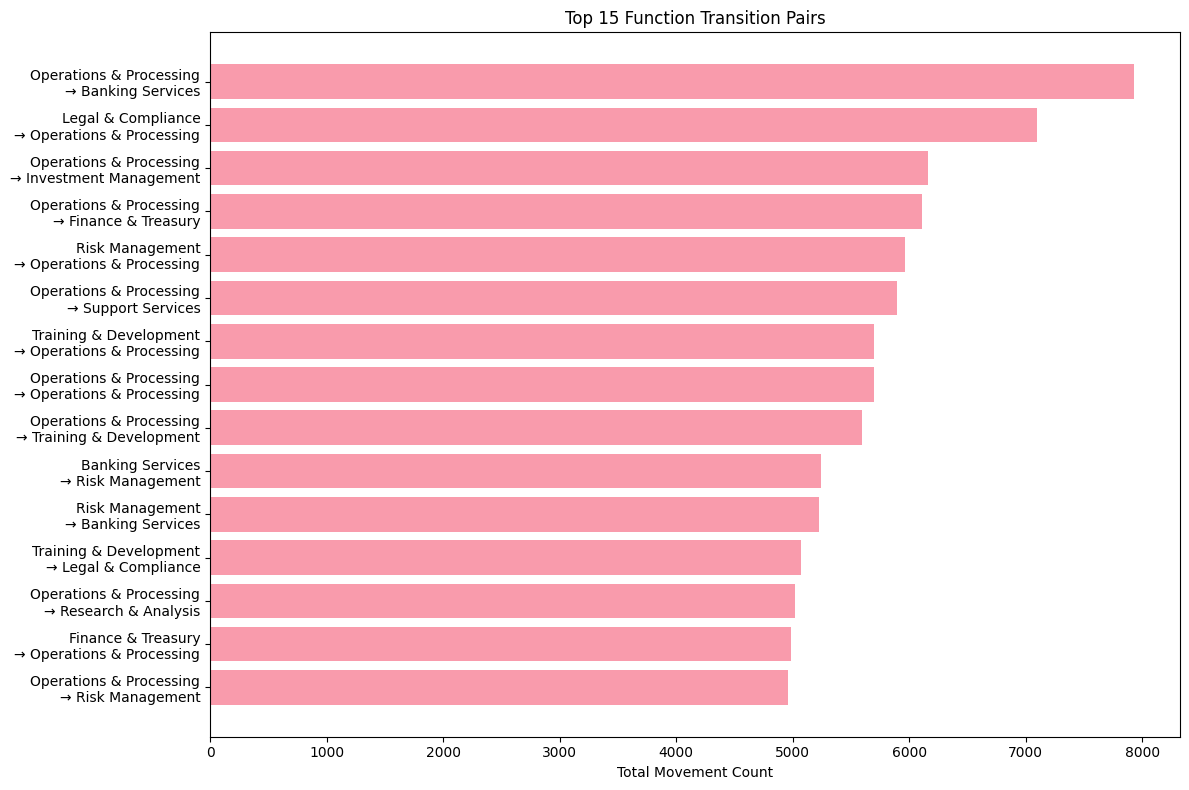

In [11]:
# Create function pair column for analysis
movement_with_function_pair = valid_movements.copy()
movement_with_function_pair['function_pair'] = (
    movement_with_function_pair['JobFunction_from'] + ' → ' + 
    movement_with_function_pair['JobFunction_to']
)

# Convert avg_days_between to months for readability
movement_with_function_pair['avg_tenure_months'] = movement_with_function_pair['avg_days_between'] / 30.44

# Top movement corridors
movement_corridors = movement_with_function_pair.groupby(['from_position', 'to_position']).agg({
    'movement_count': 'sum',
    'unique_employees': 'sum',
    'function_pair': 'first',
    'avg_tenure_months': 'mean'
}).reset_index()

movement_corridors = movement_corridors.sort_values('movement_count', ascending=False)

print("🚶 Top 20 Movement Corridors:")
print("=" * 80)
for i, row in movement_corridors.head(20).iterrows():
    print(f"{row['from_position']} → {row['to_position']}")
    print(f"  Volume: {row['movement_count']} moves, {row['unique_employees']} people")
    print(f"  Function: {row['function_pair']}")
    print(f"  Avg Tenure: {row['avg_tenure_months']:.1f} months")
    print()

# Function pair analysis
function_pair_stats = movement_with_function_pair.groupby('function_pair').agg({
    'movement_count': 'sum',
    'unique_employees': 'sum',
    'avg_tenure_months': 'mean'
}).reset_index().sort_values('movement_count', ascending=False)

print("🔄 Top 10 Function Transition Pairs:")
print("=" * 60)
for i, row in function_pair_stats.head(10).iterrows():
    print(f"{row['function_pair']}: {row['movement_count']} moves ({row['unique_employees']} people)")
    
# Visualise top function pairs
plt.figure(figsize=(12, 8))
top_pairs = function_pair_stats.head(15)
plt.barh(range(len(top_pairs)), top_pairs['movement_count'], alpha=0.7)
plt.yticks(range(len(top_pairs)), [pair.replace(' → ', '\n→ ') for pair in top_pairs['function_pair']])
plt.xlabel('Total Movement Count')
plt.title('Top 15 Function Transition Pairs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Tenure and Movement Patterns

Understanding how tenure affects movement likelihood and patterns.

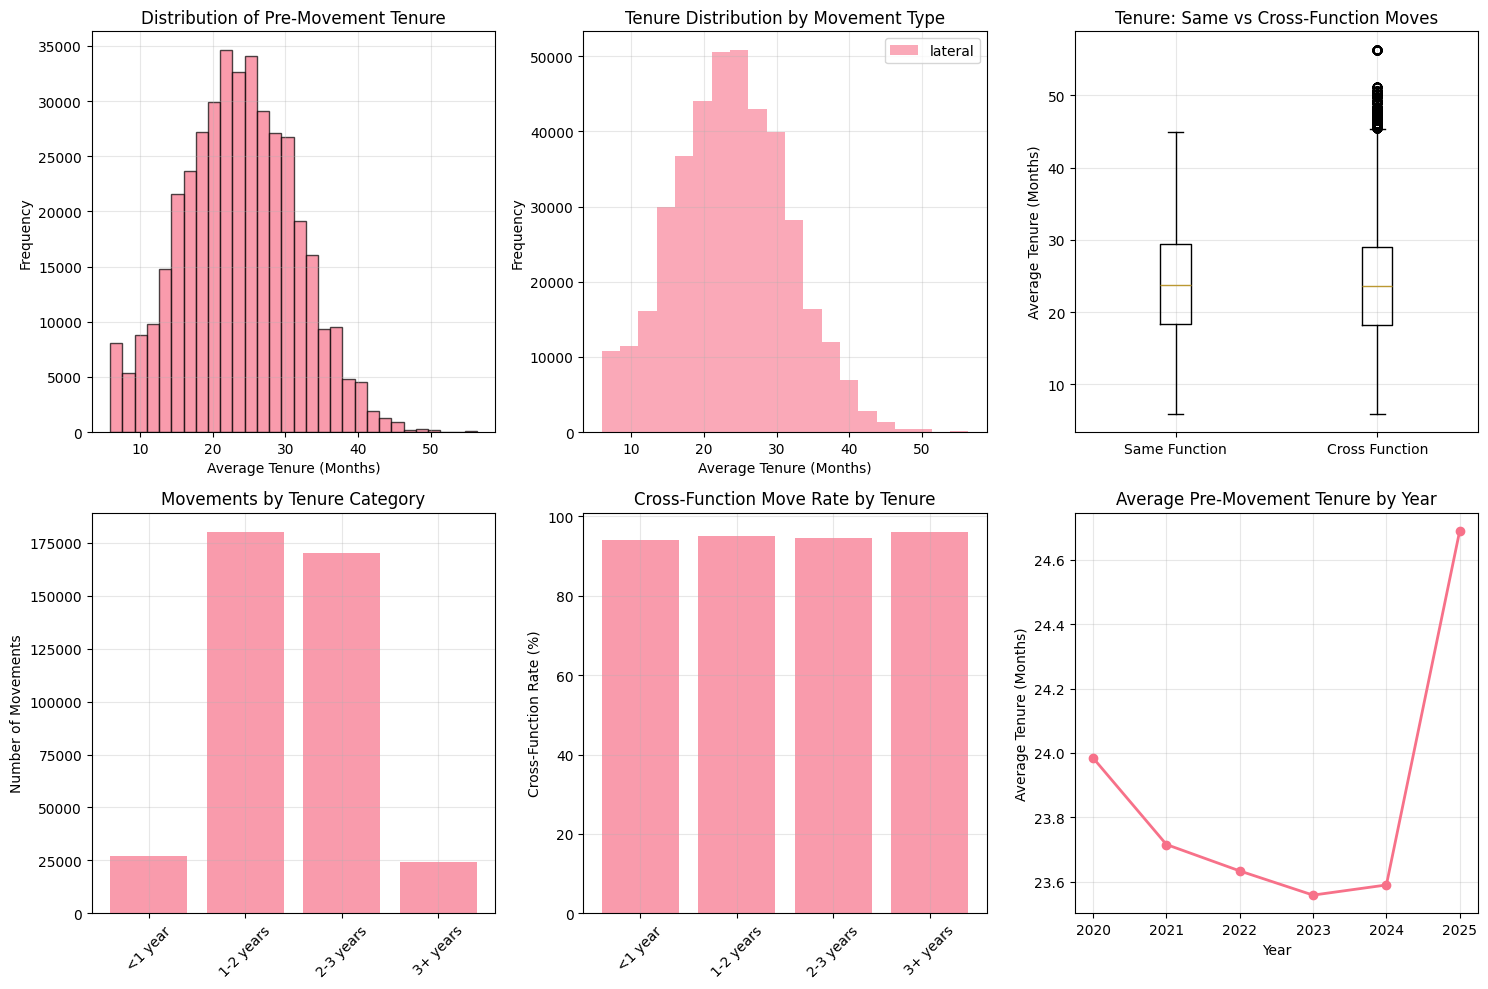

📊 Tenure Analysis Summary:
Average tenure before movement: 23.7 months
Median tenure before movement: 23.6 months
Tenure range: 5.9 - 56.4 months

🔄 Cross-Function Move Analysis by Tenure:
  <1 year: 94.1% cross-function rate (42147 total moves)
  1-2 years: 95.1% cross-function rate (273598 total moves)
  2-3 years: 94.6% cross-function rate (260170 total moves)
  3+ years: 96.1% cross-function rate (37765 total moves)


In [13]:
# Use the enhanced dataset for tenure analysis
analysis_df = movement_with_function_pair.copy()

# Tenure analysis
plt.figure(figsize=(15, 10))

# Plot 1: Tenure distribution
plt.subplot(2, 3, 1)
plt.hist(analysis_df['avg_tenure_months'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Average Tenure (Months)')
plt.ylabel('Frequency')
plt.title('Distribution of Pre-Movement Tenure')
plt.grid(True, alpha=0.3)

# Plot 2: Tenure by movement type
plt.subplot(2, 3, 2)
movement_types = analysis_df['predominant_movement_type'].unique()
for mt in movement_types:
    subset = analysis_df[analysis_df['predominant_movement_type'] == mt]
    plt.hist(subset['avg_tenure_months'], alpha=0.6, label=mt, bins=20)
plt.xlabel('Average Tenure (Months)')
plt.ylabel('Frequency')
plt.title('Tenure Distribution by Movement Type')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Tenure vs cross-function moves
plt.subplot(2, 3, 3)
cross_func = analysis_df[analysis_df['cross_function_move'] == True]['avg_tenure_months']
same_func = analysis_df[analysis_df['cross_function_move'] == False]['avg_tenure_months']
plt.boxplot([same_func, cross_func], labels=['Same Function', 'Cross Function'])
plt.ylabel('Average Tenure (Months)')
plt.title('Tenure: Same vs Cross-Function Moves')
plt.grid(True, alpha=0.3)

# Plot 4: Tenure categories
plt.subplot(2, 3, 4)
analysis_df['tenure_category'] = pd.cut(
    analysis_df['avg_tenure_months'], 
    bins=[0, 12, 24, 36, 100], 
    labels=['<1 year', '1-2 years', '2-3 years', '3+ years']
)
tenure_stats = analysis_df['tenure_category'].value_counts().sort_index()
plt.bar(range(len(tenure_stats)), tenure_stats.values, alpha=0.7)
plt.xticks(range(len(tenure_stats)), tenure_stats.index, rotation=45)
plt.ylabel('Number of Movements')
plt.title('Movements by Tenure Category')
plt.grid(True, alpha=0.3)

# Plot 5: Cross-function rate by tenure
plt.subplot(2, 3, 5)
tenure_cross_func = analysis_df.groupby('tenure_category').agg({
    'cross_function_move': 'mean',
    'movement_count': 'sum'
}).reset_index()
plt.bar(range(len(tenure_cross_func)), tenure_cross_func['cross_function_move'] * 100, alpha=0.7)
plt.xticks(range(len(tenure_cross_func)), tenure_cross_func['tenure_category'], rotation=45)
plt.ylabel('Cross-Function Rate (%)')
plt.title('Cross-Function Move Rate by Tenure')
plt.grid(True, alpha=0.3)

# Plot 6: Tenure trends over time
plt.subplot(2, 3, 6)
yearly_tenure = analysis_df.groupby('movement_year')['avg_tenure_months'].mean()
plt.plot(yearly_tenure.index, yearly_tenure.values, marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Tenure (Months)')
plt.title('Average Pre-Movement Tenure by Year')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("📊 Tenure Analysis Summary:")
print(f"Average tenure before movement: {analysis_df['avg_tenure_months'].mean():.1f} months")
print(f"Median tenure before movement: {analysis_df['avg_tenure_months'].median():.1f} months")
print(f"Tenure range: {analysis_df['avg_tenure_months'].min():.1f} - {analysis_df['avg_tenure_months'].max():.1f} months")

print(f"\n🔄 Cross-Function Move Analysis by Tenure:")
for category in tenure_cross_func['tenure_category']:
    rate = tenure_cross_func[tenure_cross_func['tenure_category'] == category]['cross_function_move'].iloc[0]
    count = tenure_cross_func[tenure_cross_func['tenure_category'] == category]['movement_count'].iloc[0]
    print(f"  {category}: {rate*100:.1f}% cross-function rate ({count} total moves)")

## 5. Data Quality Assessment

Final assessment of data completeness and patterns for next phase analysis.

In [ ]:
# Data quality checks
print("🔍 Data Quality Assessment")
print("=" * 50)

# Movement data completeness
movement_completeness = movement_df.isnull().sum() / len(movement_df) * 100
print(f"\n📊 Movement Data Completeness:")
for col, pct in movement_completeness.items():
    if pct > 0:
        print(f"  {col}: {100-pct:.1f}% complete ({pct:.1f}% missing)")
    else:
        print(f"  {col}: 100% complete")

# Job context merge success rate
merge_success = (movement_with_context['JobFunction_from'].notna() & 
                movement_with_context['JobFunction_to'].notna()).mean() * 100
print(f"\n🔗 Job Context Merge Success: {merge_success:.1f}%")

# Check for unique position coverage using the positions table
positions_in_movement = set(movement_df['from_position']) | set(movement_df['to_position'])
positions_in_positions_table = set(positions_df['Position Number'])
position_coverage = len(positions_in_movement & positions_in_positions_table) / len(positions_in_movement) * 100
print(f"📋 Position Coverage in Positions Table: {position_coverage:.1f}%")

# Movement patterns validation
print(f"\n🔄 Movement Pattern Validation:")
print(f"  Total movement records: {len(movement_df):,}")
print(f"  Unique from positions: {movement_df['from_position'].nunique():,}")
print(f"  Unique to positions: {movement_df['to_position'].nunique():,}")
print(f"  Unique position pairs: {movement_df[['from_position', 'to_position']].drop_duplicates().shape[0]:,}")

# Temporal consistency
print(f"\n📅 Temporal Patterns:")
print(f"  Date range: {movement_df['movement_year'].min()} - {movement_df['movement_year'].max()}")
print(f"  Months covered: {movement_df['movement_month'].nunique()}")
print(f"  Average movements per month: {movement_df['movement_count'].sum() / movement_df['movement_month'].nunique():.1f}")

# Cross-function analysis (using the enriched dataset)
cross_function_count = analysis_df['cross_function_move'].sum()
total_valid_moves = len(analysis_df)
cross_function_rate = (cross_function_count / total_valid_moves) * 100

# Summary for next phase
print(f"\n✅ Ready for Next Phase:")
print(f"  ✓ Movement data loaded: {len(movement_df):,} records")
print(f"  ✓ Job context available: {merge_success:.1f}% coverage")
print(f"  ✓ Cross-function moves identified: {cross_function_count:,} ({cross_function_rate:.1f}%)")
print(f"  ✓ Tenure data available for analysis")
print(f"  ✓ Function-level patterns established")

# Close database connection
conn.close()
print(f"\n📊 Analysis complete - ready for feature importance evaluation!")

🔍 Data Quality Assessment

📊 Movement Data Completeness:
  fact_id: 100% complete
  movement_month: 100% complete
  movement_year: 100% complete
  from_position: 100% complete
  to_position: 100% complete
  movement_pattern: 100% complete
  movement_count: 100% complete
  pct_total_movements: 100% complete
  unique_employees: 100% complete
  avg_days_between: 100% complete
  monthly_total_movements: 100% complete
  predominant_movement_type: 100% complete
  date: 100% complete

🔗 Job Context Merge Success: 100.0%
📋 Position Coverage in Positions Table: 100.0%

🔄 Movement Pattern Validation:
  Total movement records: 8,422
  Unique from positions: 1,286
  Unique to positions: 1,283
  Unique position pairs: 1,485

📅 Temporal Patterns:
  Date range: 2020 - 2025
  Months covered: 55
  Average movements per month: 232.8

✅ Ready for Next Phase:
  ✓ Movement data loaded: 8,422 records
  ✓ Job context available: 100.0% coverage
  ✓ Cross-function moves identified: 380,942 (94.9%)
  ✓ Tenure d